# Gas and Ridership Visualization

In [ ]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

In [ ]:
# Reads fuel price data
gas_weekly = pd.read_csv("../../data/02-processed/nyc_gas_prices_weekly_2023.csv")
gas_weekly.rename(columns={'Date':"date"}, inplace=True)
print(gas_weekly.head())

# Reads ridership data
ridership_weekly = pd.read_csv("../../data/01-interim/MTA_subway/MTA_Subway_Weekly_Manhattan_Totals.csv")
print(ridership_weekly.head())


# Turn datasets into dataframe
ridership_weekly['date'] = pd.to_datetime(ridership_weekly['date'])
gas_weekly['date'] = pd.to_datetime(gas_weekly['date'])
# Make it the same week
ridership_weekly['week'] = ridership_weekly['date'] - pd.to_timedelta(ridership_weekly['date'].dt.dayofweek, unit='D')
gas_weekly['week'] = gas_weekly['date'] - pd.to_timedelta(gas_weekly['date'].dt.dayofweek, unit='D')
# Merge
df = pd.merge(ridership_weekly, gas_weekly, on='week', how='inner')
df = df.rename(columns={
    "ridership_y": "gas_price",
    "ridership_x": "ridership",
    "date_x": "ridership_date",
    "date_y": "gas_price_date"
})
df.head()

         date  gas_price_dollars_per_gallon
0  2023-01-02                         3.247
1  2023-01-09                         3.231
2  2023-01-16                         3.259
3  2023-01-23                         3.367
4  2023-01-30                         3.428
         date  ridership
0  2023-01-01    1013185
1  2023-01-08   10290807
2  2023-01-15   11188333
3  2023-01-22   10738820
4  2023-01-29   11498691


,ridership_date,ridership,week,gas_price_date,gas_price_dollars_per_gallon
0,2023-01-08,10290807,2023-01-02,2023-01-02,3.247
1,2023-01-15,11188333,2023-01-09,2023-01-09,3.231
2,2023-01-22,10738820,2023-01-16,2023-01-16,3.259
3,2023-01-29,11498691,2023-01-23,2023-01-23,3.367
4,2023-02-05,11294077,2023-01-30,2023-01-30,3.428


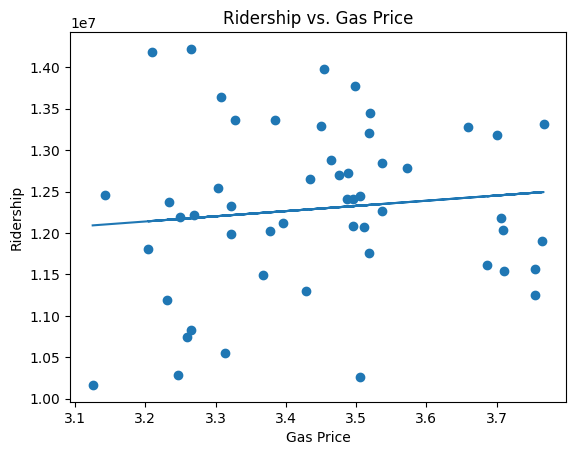

In [12]:
m, b = np.polyfit(df['gas_price_dollars_per_gallon'], df['ridership'], 1)
plt.scatter(df['gas_price_dollars_per_gallon'], df['ridership'])
plt.plot(df['gas_price_dollars_per_gallon'], m*df['gas_price_dollars_per_gallon'] + b)
plt.xlabel("Gas Price")
plt.ylabel("Ridership")
plt.title('Ridership vs. Gas Price')
plt.savefig('ridership_gas_price_scatter_plot.png')
plt.show()

In [14]:
# Correlation Factor
print(round(df['gas_price'].corr(df['ridership']), 3))

0.11


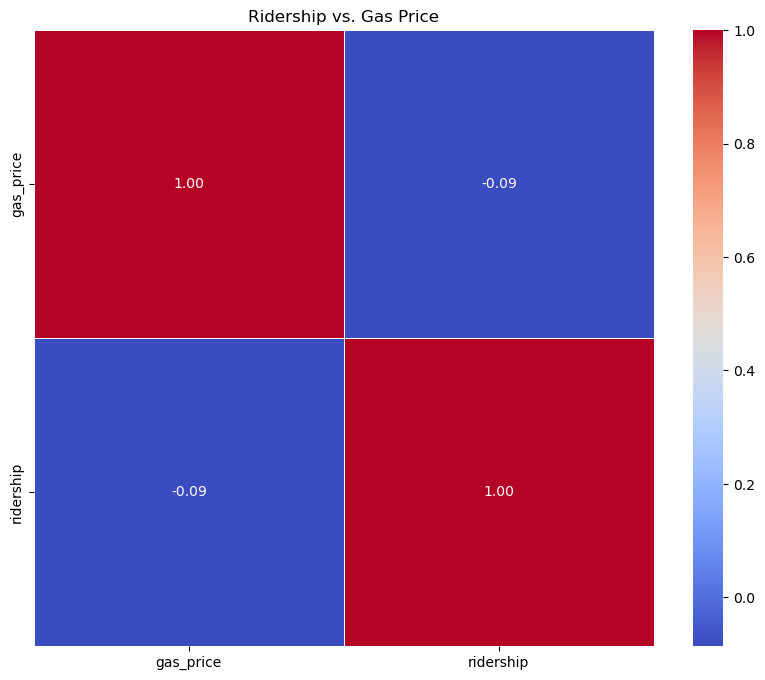

In [ ]:
# Reads fuel price data
gas_weekly = pd.read_csv("../../data/02-processed/nyc_gas_prices_weekly_2023.csv")
gas_weekly.rename(columns={'Date':"date"}, inplace=True)
print(gas_weekly.head())

# Reads MTA ridership data
mta_daily = pd.read_csv("../../data/02-processed/daily_total_ridership.csv")
print(mta_daily.head())


# Turn datasets into dataframe
mta_weekly['date'] = pd.to_datetime(mta_weekly['date'])
gas_weekly['date'] = pd.to_datetime(gas_weekly['date'])
# Make it the same week
mta_weekly['week'] = mta_weekly['date'] - pd.to_timedelta(mta_weekly['date'].dt.dayofweek, unit='D')
gas_weekly['week'] = gas_weekly['date'] - pd.to_timedelta(gas_weekly['date'].dt.dayofweek, unit='D')
# Merge
df = pd.merge(mta_weekly, gas_weekly, on='week', how='inner')
df = df.rename(columns={
    "mta_y": "gas_price",
    "mta_x": "mta",
    "date_x": "mta_date",
    "date_y": "gas_price_date"
})
df.head()